In [ ]:
import sys
import subprocess
import importlib

def pip_install(*packages):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *packages])

required = [
    "scanpy",
    "anndata",
    "leidenalg",
    "igraph",
    "harmonypy",
    "seaborn"
]
pip_install(*required)

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
import anndata as ad

sc.settings.verbosity = 2
sc.settings.set_figure_params(dpi=110, facecolor="white", frameon=False)
np.random.seed(42)

print("Scanpy version:", sc.__version__)

adata = sc.datasets.pbmc3k()
adata.var_names_make_unique()

print("\nInitial AnnData:")
print(adata)

adata.layers["counts"] = adata.X.copy()

adata.var["mt"] = adata.var_names.str.upper().str.startswith("MT-")
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True)

print("\nQC summary:")
display(
    adata.obs[["n_genes_by_counts", "total_counts", "pct_counts_mt"]].describe().T
)

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
sc.pl.violin(adata, ["n_genes_by_counts"], jitter=0.4, ax=axs[0], show=False)
sc.pl.violin(adata, ["total_counts"], jitter=0.4, ax=axs[1], show=False)
sc.pl.violin(adata, ["pct_counts_mt"], jitter=0.4, ax=axs[2], show=False)
plt.tight_layout()
plt.show()

sc.pl.scatter(adata, x="total_counts", y="n_genes_by_counts", color="pct_counts_mt")

adata = adata[adata.obs["n_genes_by_counts"] >= 200].copy()
adata = adata[adata.obs["n_genes_by_counts"] <= 5000].copy()
adata = adata[adata.obs["pct_counts_mt"] < 10].copy()
sc.pp.filter_genes(adata, min_cells=3)

print("\nAfter filtering:")
print(adata)

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.raw = adata.copy()

sc.pp.highly_variable_genes(
    adata,
    flavor="seurat",
    min_mean=0.0125,
    max_mean=3,
    min_disp=0.5
)

print("\nHighly variable genes selected:", int(adata.var["highly_variable"].sum()))

sc.pl.highly_variable_genes(adata)

adata = adata[:, adata.var["highly_variable"]].copy()

In [ ]:
sc.pp.regress_out(adata, ["total_counts", "pct_counts_mt"])
sc.pp.scale(adata, max_value=10)

sc.tl.pca(adata, svd_solver="arpack")
sc.pl.pca_variance_ratio(adata, log=True)
sc.pl.pca(adata, color=None)

sc.pp.neighbors(adata, n_neighbors=12, n_pcs=30, metric="euclidean")
sc.tl.umap(adata, min_dist=0.35, spread=1.0)
sc.tl.leiden(adata, resolution=0.6, key_added="leiden")

print("\nCluster counts:")
display(adata.obs["leiden"].value_counts().sort_index().rename("cells_per_cluster").to_frame())

sc.pl.umap(adata, color=["leiden"], legend_loc="on data", title="PBMC 3k - Leiden clusters")

sc.tl.rank_genes_groups(adata, groupby="leiden", method="wilcoxon")
sc.pl.rank_genes_groups(adata, n_genes=20, sharey=False)

marker_table = sc.get.rank_genes_groups_df(adata, group=None)
print("\nTop marker rows:")
display(marker_table.head(20))

In [ ]:
top_markers_per_cluster = (
    marker_table.groupby("group")
    .head(10)
    .loc[:, ["group", "names", "logfoldchanges", "pvals_adj"]]
    .reset_index(drop=True)
)
print("\nTop 10 markers per cluster:")
display(top_markers_per_cluster)

candidate_markers = [
    "IL7R", "LTB", "MALAT1", "CCR7",
    "NKG7", "GNLY", "PRF1",
    "MS4A1", "CD79A", "CD79B",
    "LYZ", "S100A8", "FCER1A", "CST3",
    "PPBP", "FCGR3A", "LGALS3", "CTSS",
    "CD3D", "TRBC1", "TRAC"
]
candidate_markers = [g for g in candidate_markers if g in adata.var_names]

if candidate_markers:
    sc.pl.dotplot(
        adata,
        var_names=candidate_markers,
        groupby="leiden",
        standard_scale="var",
        dendrogram=True
    )
    sc.pl.matrixplot(
        adata,
        var_names=candidate_markers,
        groupby="leiden",
        standard_scale="var",
        dendrogram=True
    )

cluster_marker_reference = {
    "T_cells": ["IL7R", "LTB", "CCR7", "CD3D", "TRBC1", "TRAC"],
    "NK_cells": ["NKG7", "GNLY", "PRF1"],
    "B_cells": ["MS4A1", "CD79A", "CD79B"],
    "Monocytes": ["LYZ", "FCGR3A", "LGALS3", "CTSS", "S100A8", "CST3"],
    "Dendritic_cells": ["FCER1A", "CST3"],
    "Platelets": ["PPBP"]
}

Scanpy version: 1.12
try downloading from url
https://falexwolf.de/data/pbmc3k_raw.h5ad
... this may take a while but only happens once


  0%|          | 0.00/5.58M [00:00<?, ?B/s]


Initial AnnData:
AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'

QC summary:


,count,mean,std,min,25%,50%,75%,max
n_genes_by_counts,2700.0,846.994074,282.104964,212.0,690.000000,817.000000,953.250000,3422.000000
total_counts,2700.0,2366.900391,1094.261963,548.0,1757.750000,2197.000000,2763.000000,15844.000000
pct_counts_mt,2700.0,2.215132,1.165438,0.0,1.536238,2.029639,2.640218,22.569027


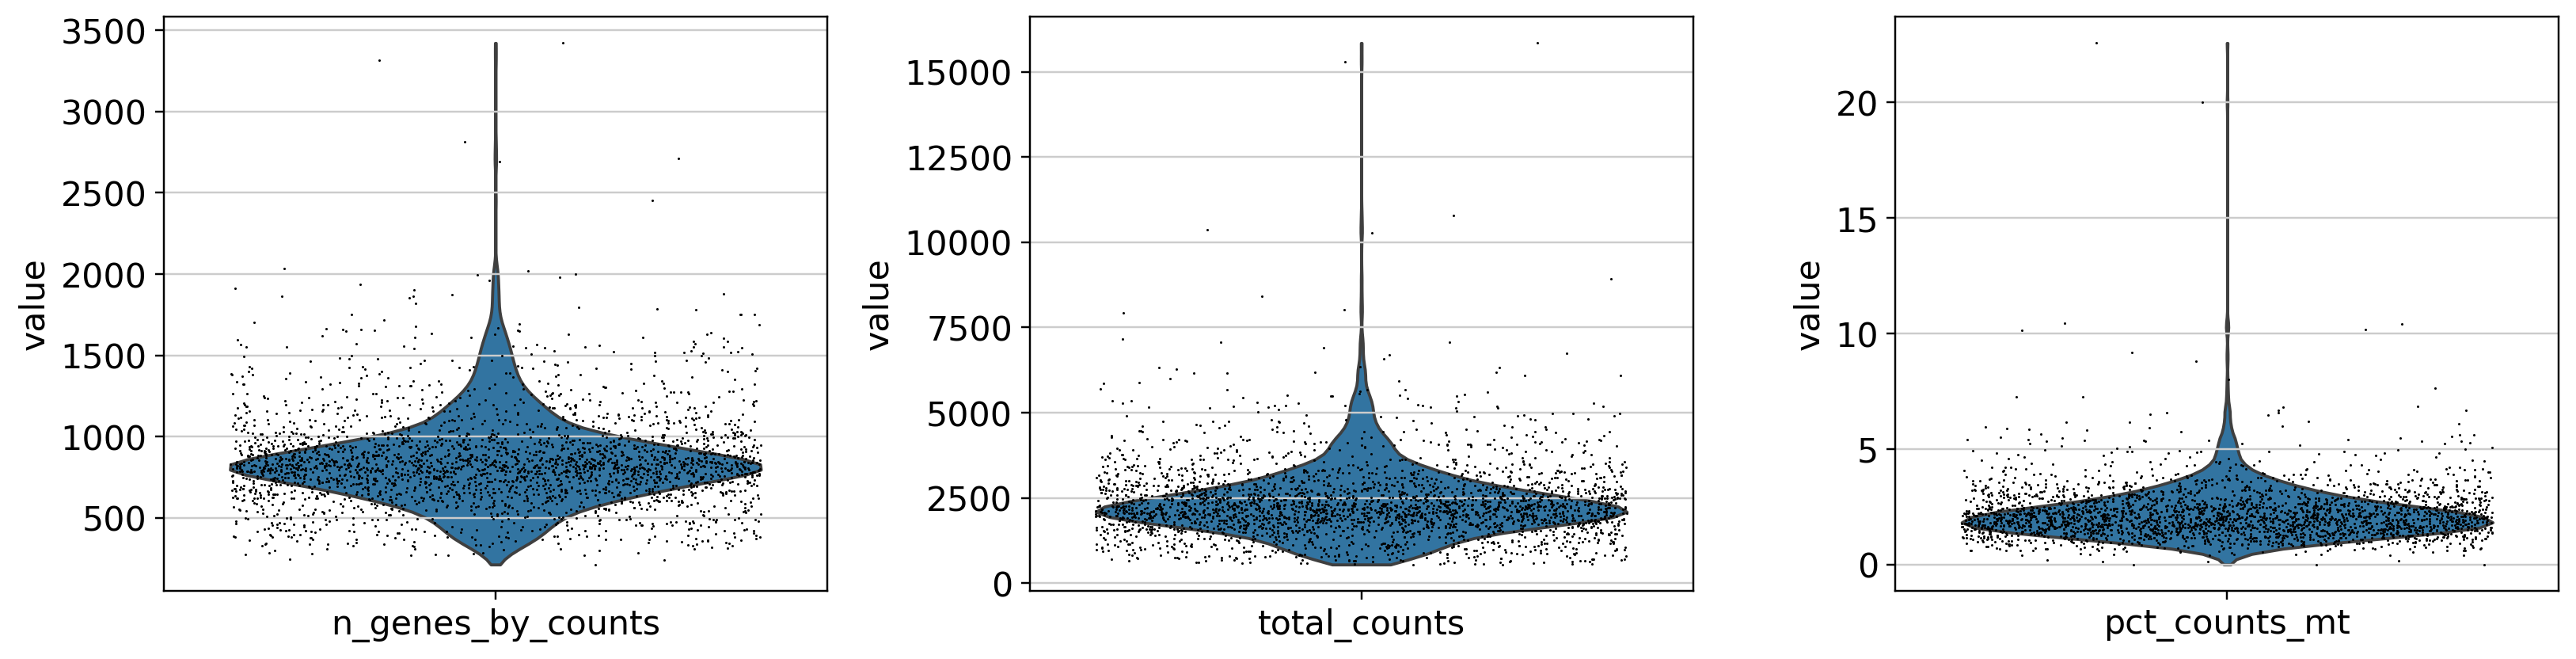

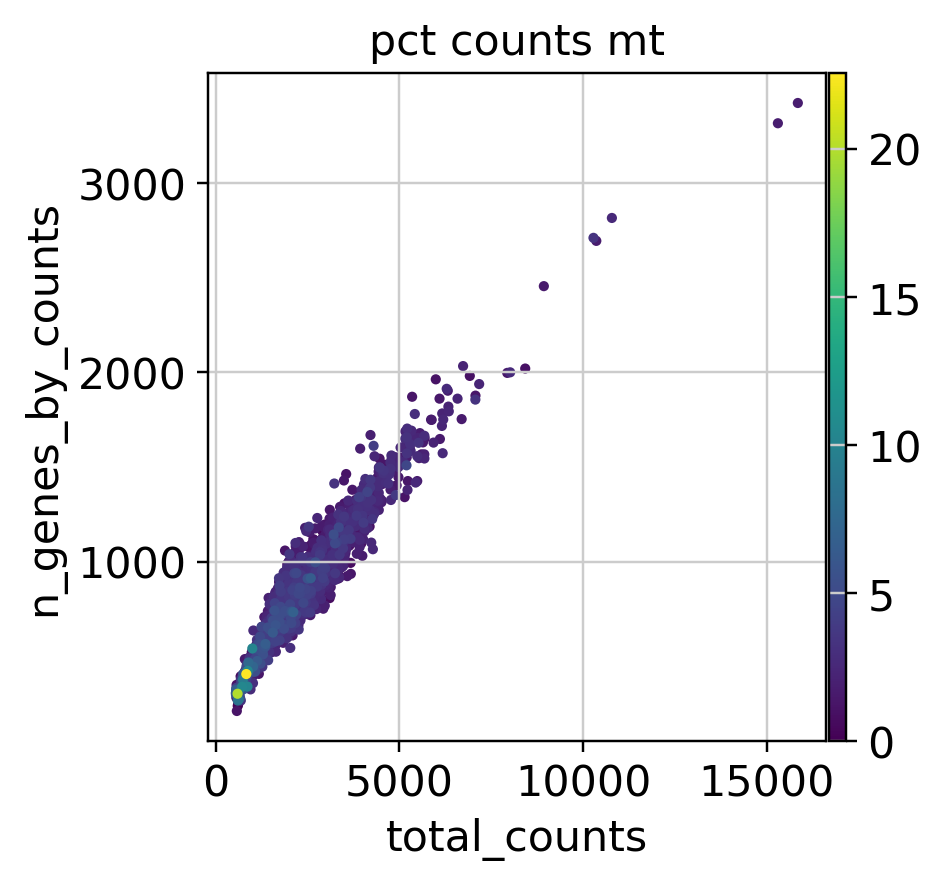

filtered out 19026 genes that are detected in less than 3 cells

After filtering:
AnnData object with n_obs × n_vars = 2694 × 13712
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    layers: 'counts'
normalizing counts per cell
    finished (0:00:05)
extracting highly variable genes
    finished (0:00:01)

Highly variable genes selected: 1860


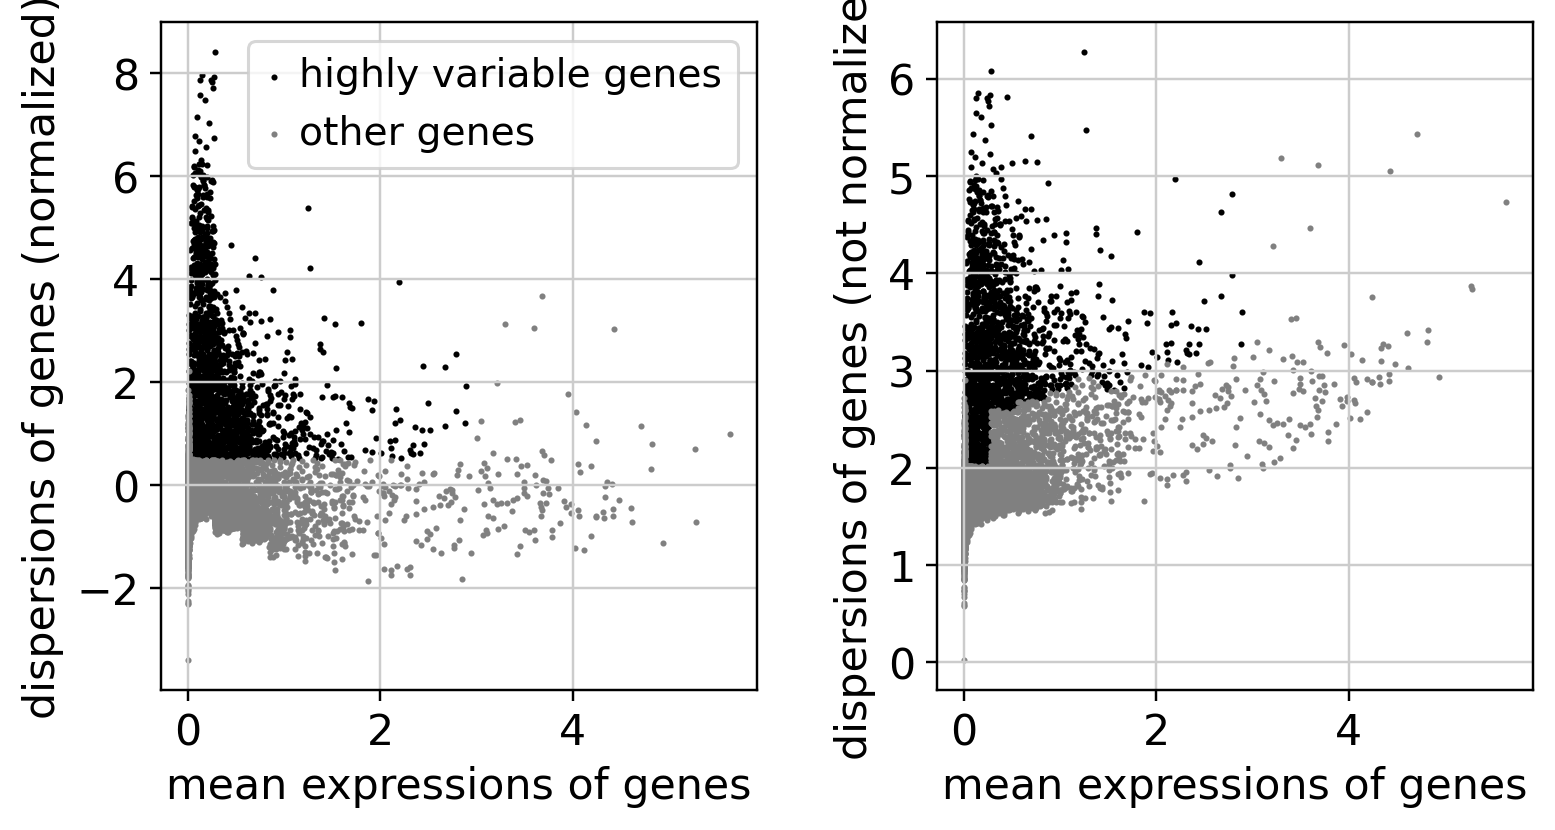

regressing out ['total_counts', 'pct_counts_mt']
    sparse input is densified and may lead to high memory use
    finished (0:00:02)
computing PCA
    with n_comps=50
    finished (0:00:01)


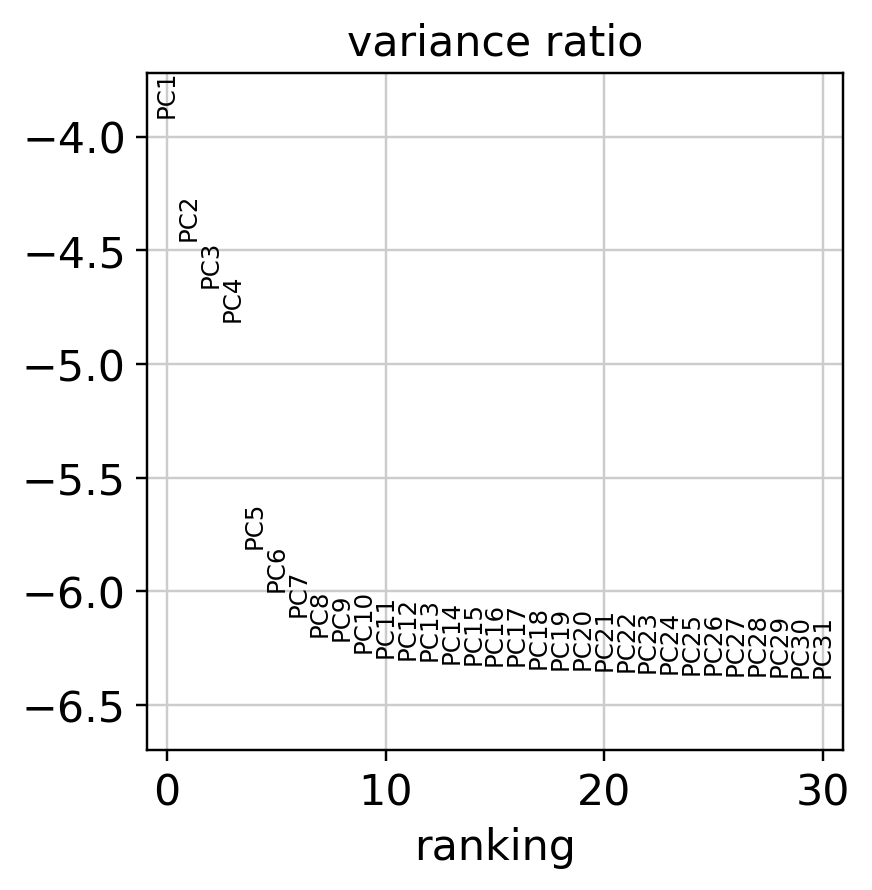

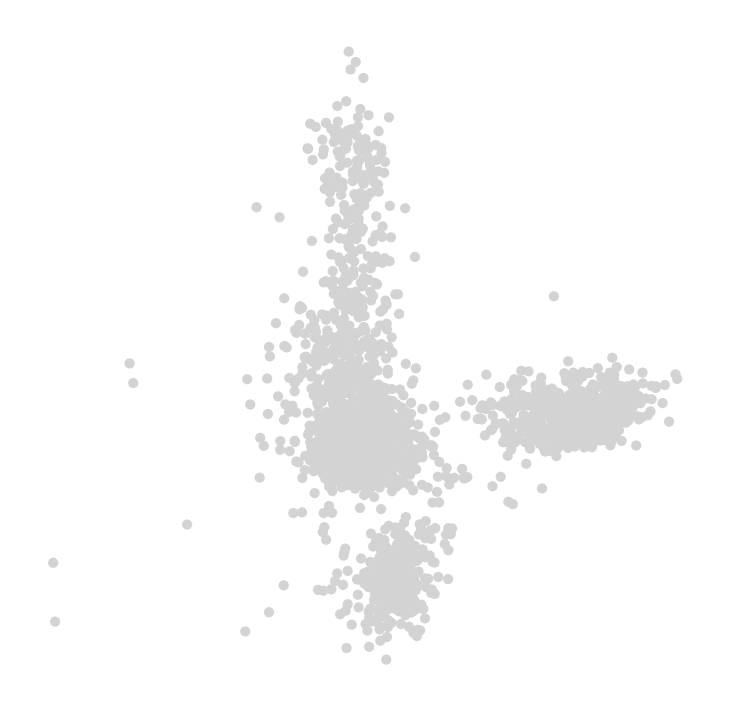

computing neighbors
    using 'X_pca' with n_pcs = 30
    finished (0:00:59)
computing UMAP
    finished (0:00:05)
running Leiden clustering
    finished (0:00:00)

Cluster counts:


,cells_per_cluster
leiden,
0,1198
1,475
2,448
3,352
4,172
5,36
6,13


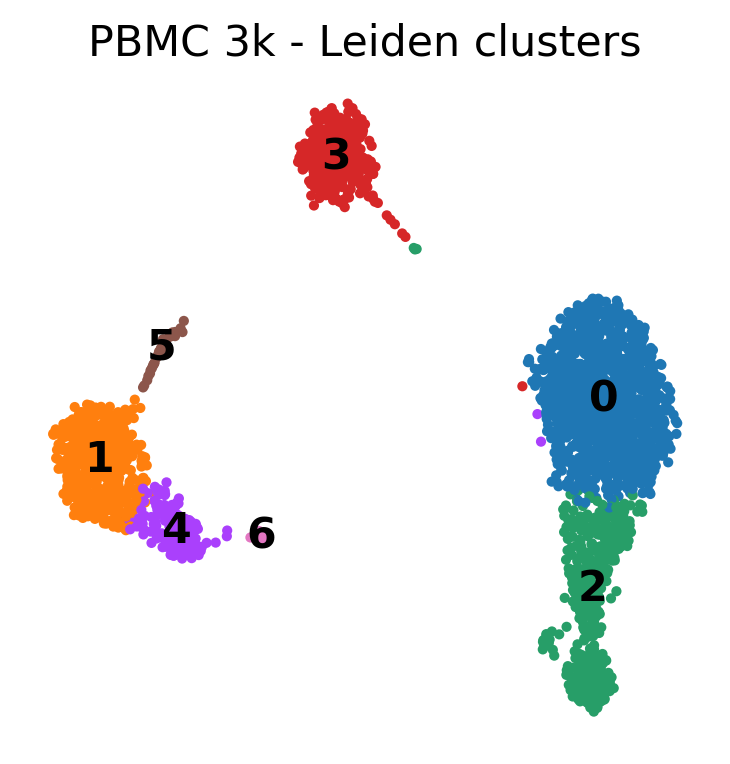

ranking genes
    finished (0:00:11)


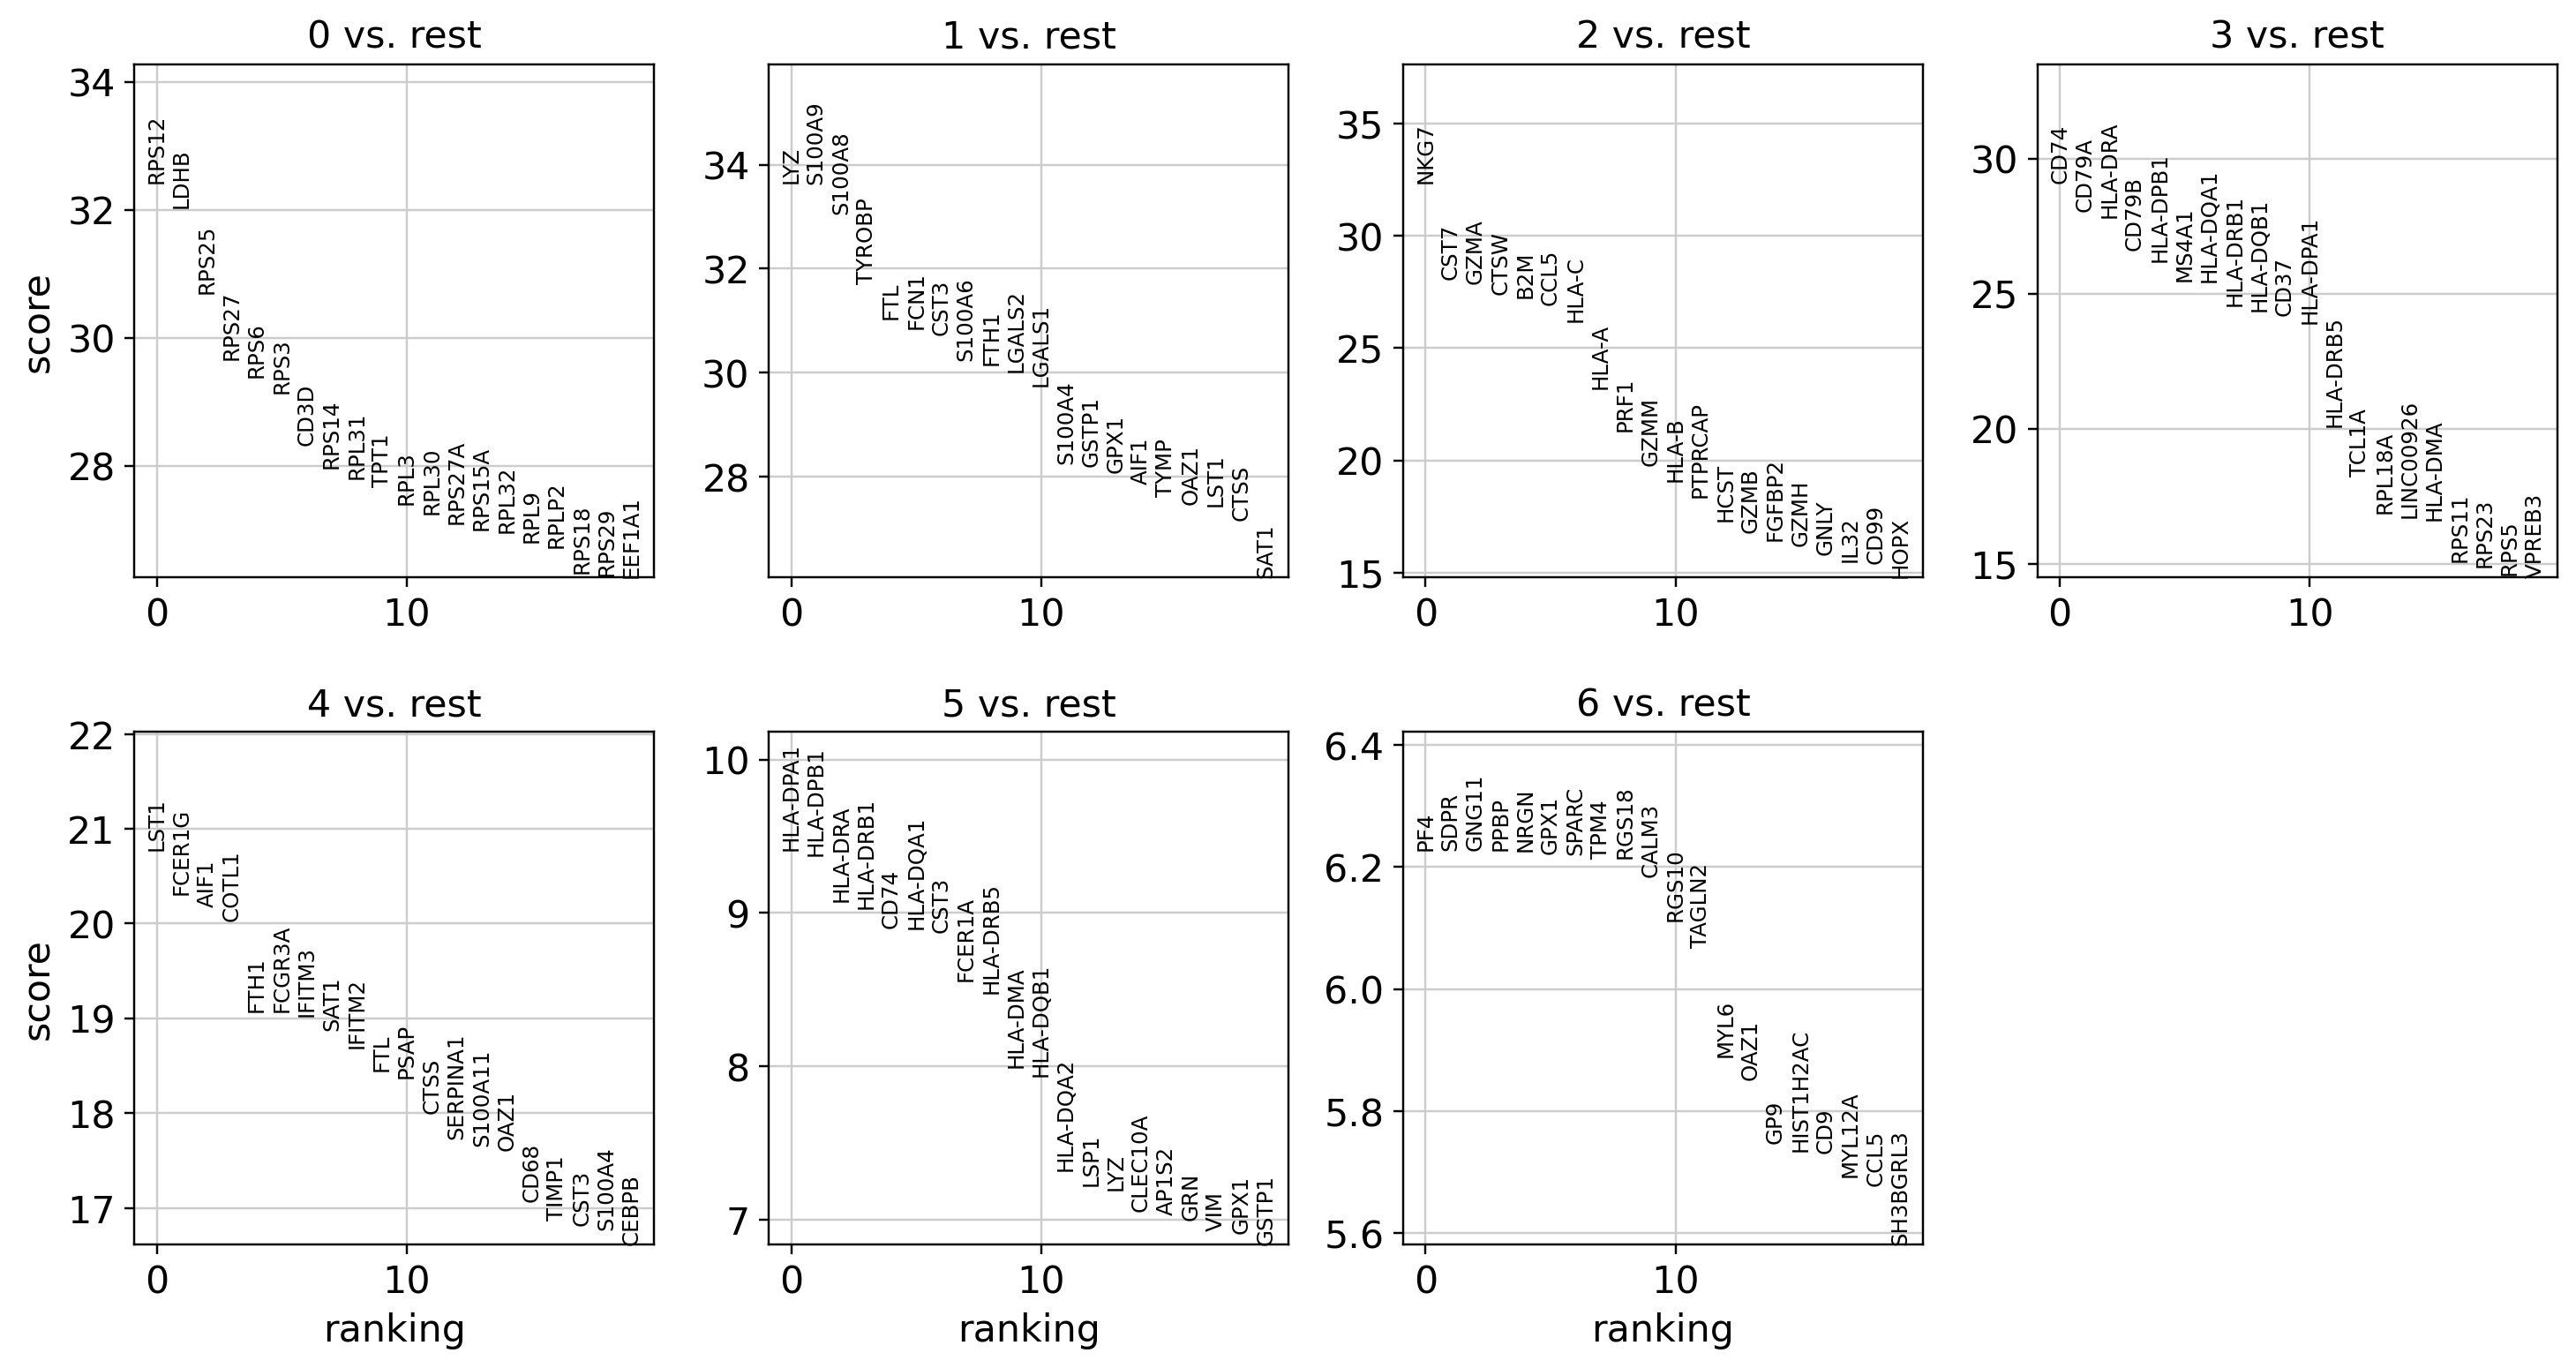


Top marker rows:


,group,names,scores,logfoldchanges,pvals,pvals_adj
0,0,RPS12,32.424927,1.050467,1.222532e-230,1.676336e-226
1,0,LDHB,32.035419,2.690089,3.504419e-225,2.402630e-221
2,0,RPS25,30.700783,1.172160,5.556382e-207,1.523782e-203
3,0,RPS27,29.659357,1.017045,2.568924e-193,4.403135e-190
4,0,RPS6,29.381176,0.855113,9.555729e-190,1.455868e-186
5,0,RPS3,29.141298,0.864515,1.076875e-186,1.476611e-183
6,0,CD3D,28.321630,3.217735,1.871840e-176,2.333333e-173
7,0,RPS14,27.965616,0.757973,4.257698e-172,4.490889e-169
8,0,RPL31,27.801056,1.134615,4.212136e-170,3.850454e-167
9,0,TPT1,27.680904,0.936248,1.185544e-168,1.016011e-165



Top 10 markers per cluster:


,group,names,logfoldchanges,pvals_adj
0,0,RPS12,1.050467,1.676336e-226
1,0,LDHB,2.690089,2.402630e-221
2,0,RPS25,1.172160,1.523782e-203
3,0,RPS27,1.017045,4.403135e-190
4,0,RPS6,0.855113,1.455868e-186
...,...,...,...,...
65,6,GPX1,6.482230,7.786763e-07
66,6,SPARC,10.837226,7.786763e-07
67,6,TPM4,6.951354,7.786763e-07
68,6,RGS18,8.637442,7.786763e-07


    using 'X_pca' with n_pcs = 50
Storing dendrogram info using `.uns['dendrogram_leiden']`


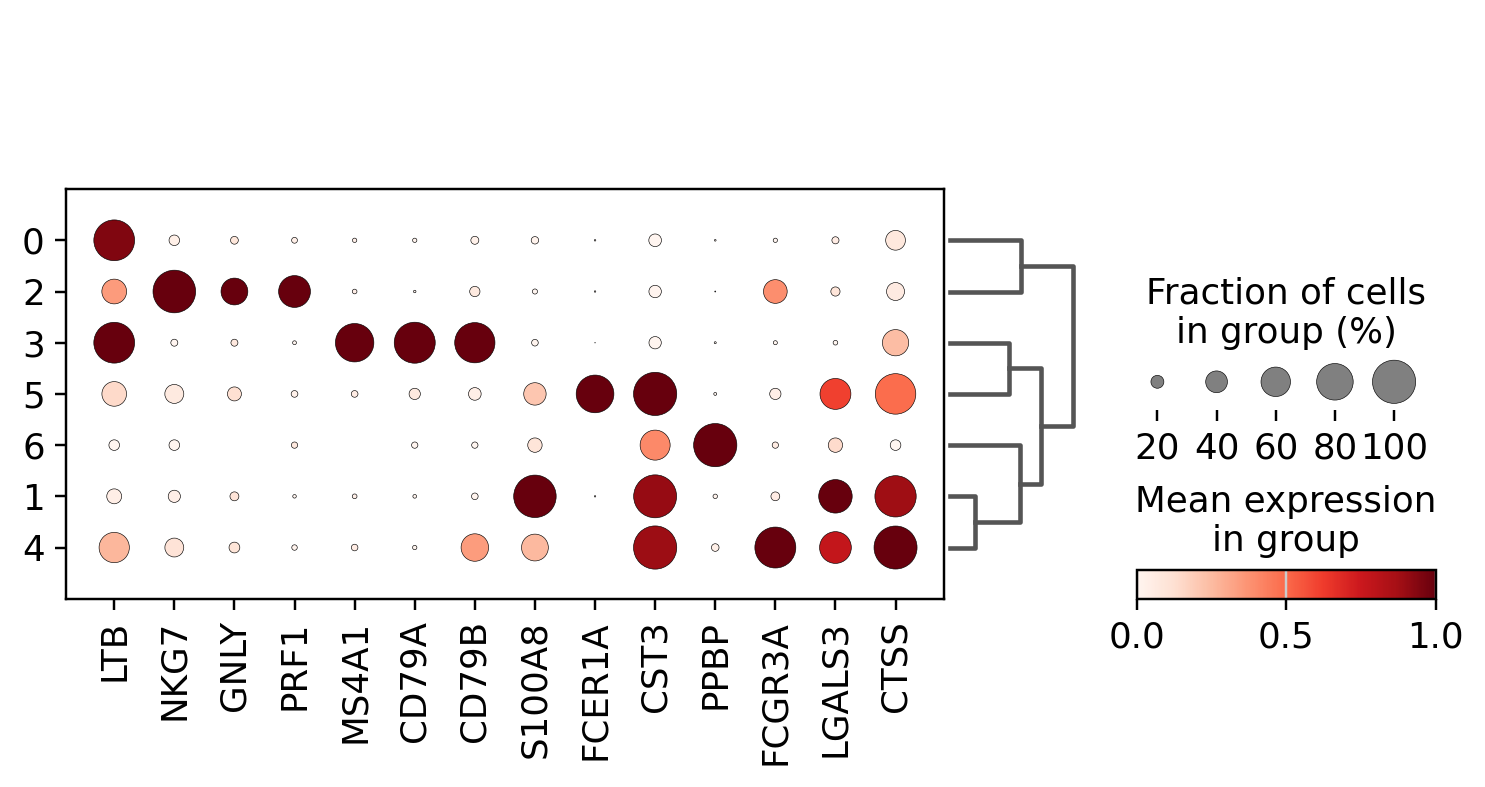

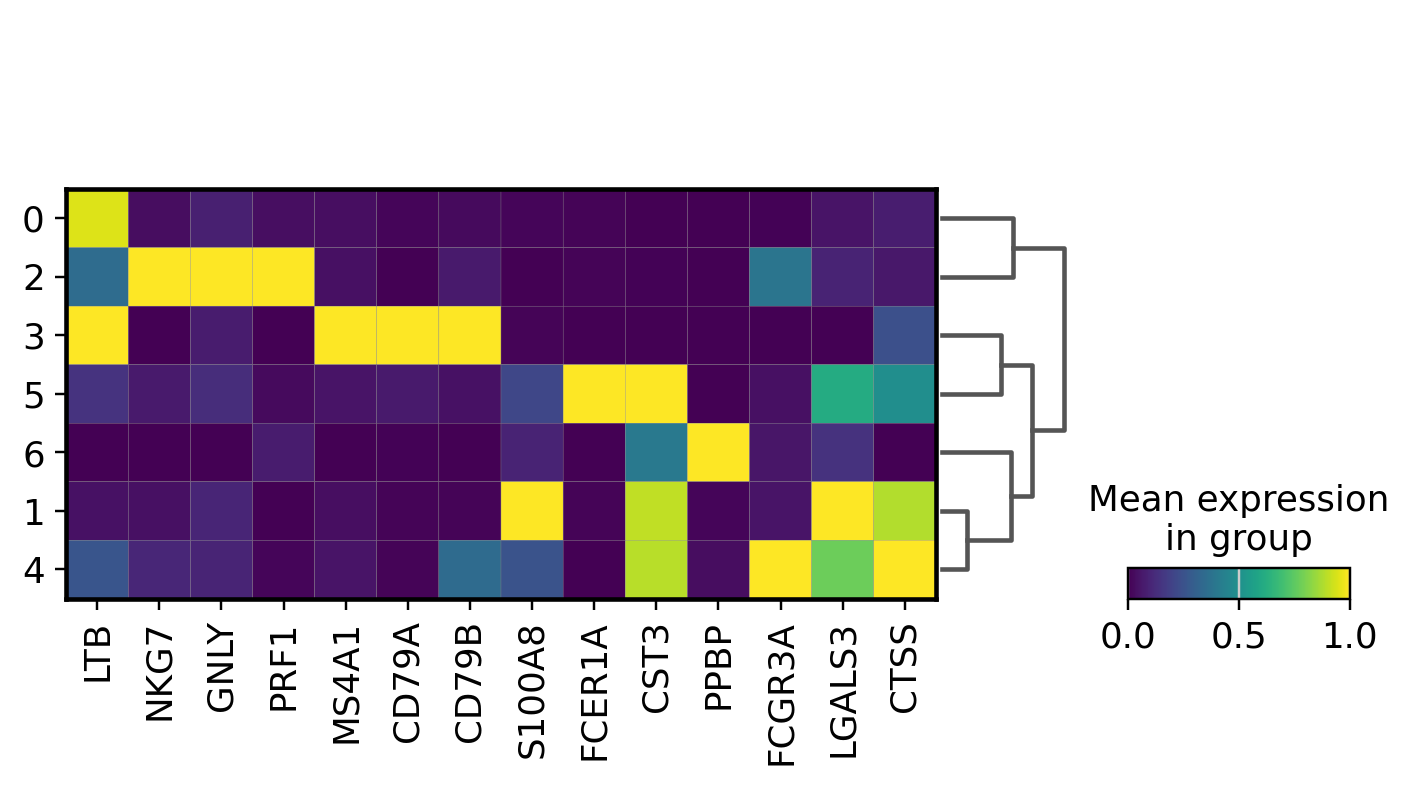

computing score 'T_cells_score'
    finished (0:00:00)
computing score 'NK_cells_score'
    finished (0:00:00)
computing score 'B_cells_score'
    finished (0:00:00)
computing score 'Monocytes_score'
    finished (0:00:00)
computing score 'Dendritic_cells_score'
    finished (0:00:00)
computing score 'Platelets_score'
    finished (0:00:00)


,T_cells_score,NK_cells_score,B_cells_score,Monocytes_score,Dendritic_cells_score,Platelets_score
leiden,,,,,,
0,0.562555,-0.225988,-0.278477,-0.367846,-0.270626,-0.072095
1,-0.998108,-0.423681,-0.421931,1.104409,0.758682,0.019066
2,-0.604786,1.475831,-0.436611,-0.291691,-0.325617,-0.143621
3,0.611147,-0.389562,2.125647,-0.359453,-0.271736,-0.101601
4,-0.595718,-0.255530,-0.068947,0.985809,0.431565,0.343463
5,-0.804451,-0.117815,-0.077144,0.072242,3.509457,0.000624
6,-0.968913,-0.297850,-0.304322,0.086918,0.385675,9.175895



Cluster to cell-type mapping:


,assigned_cell_type
0,T_cells
1,Monocytes
2,NK_cells
3,B_cells
4,Monocytes
5,Dendritic_cells
6,Platelets


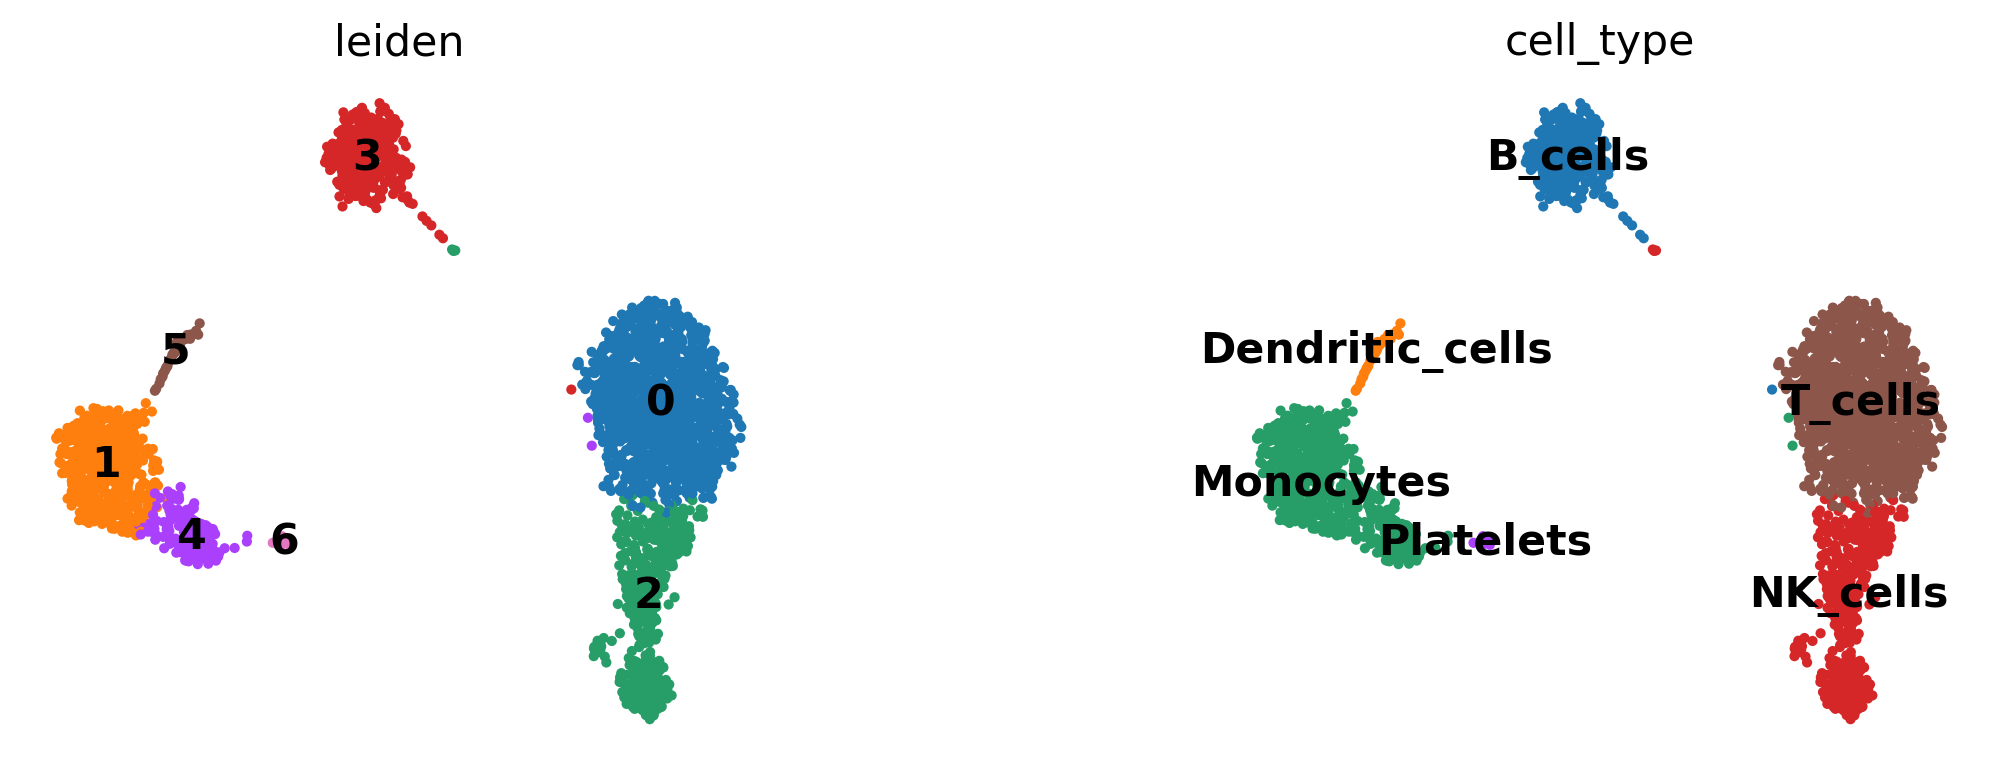

ranking genes
    finished (0:00:03)


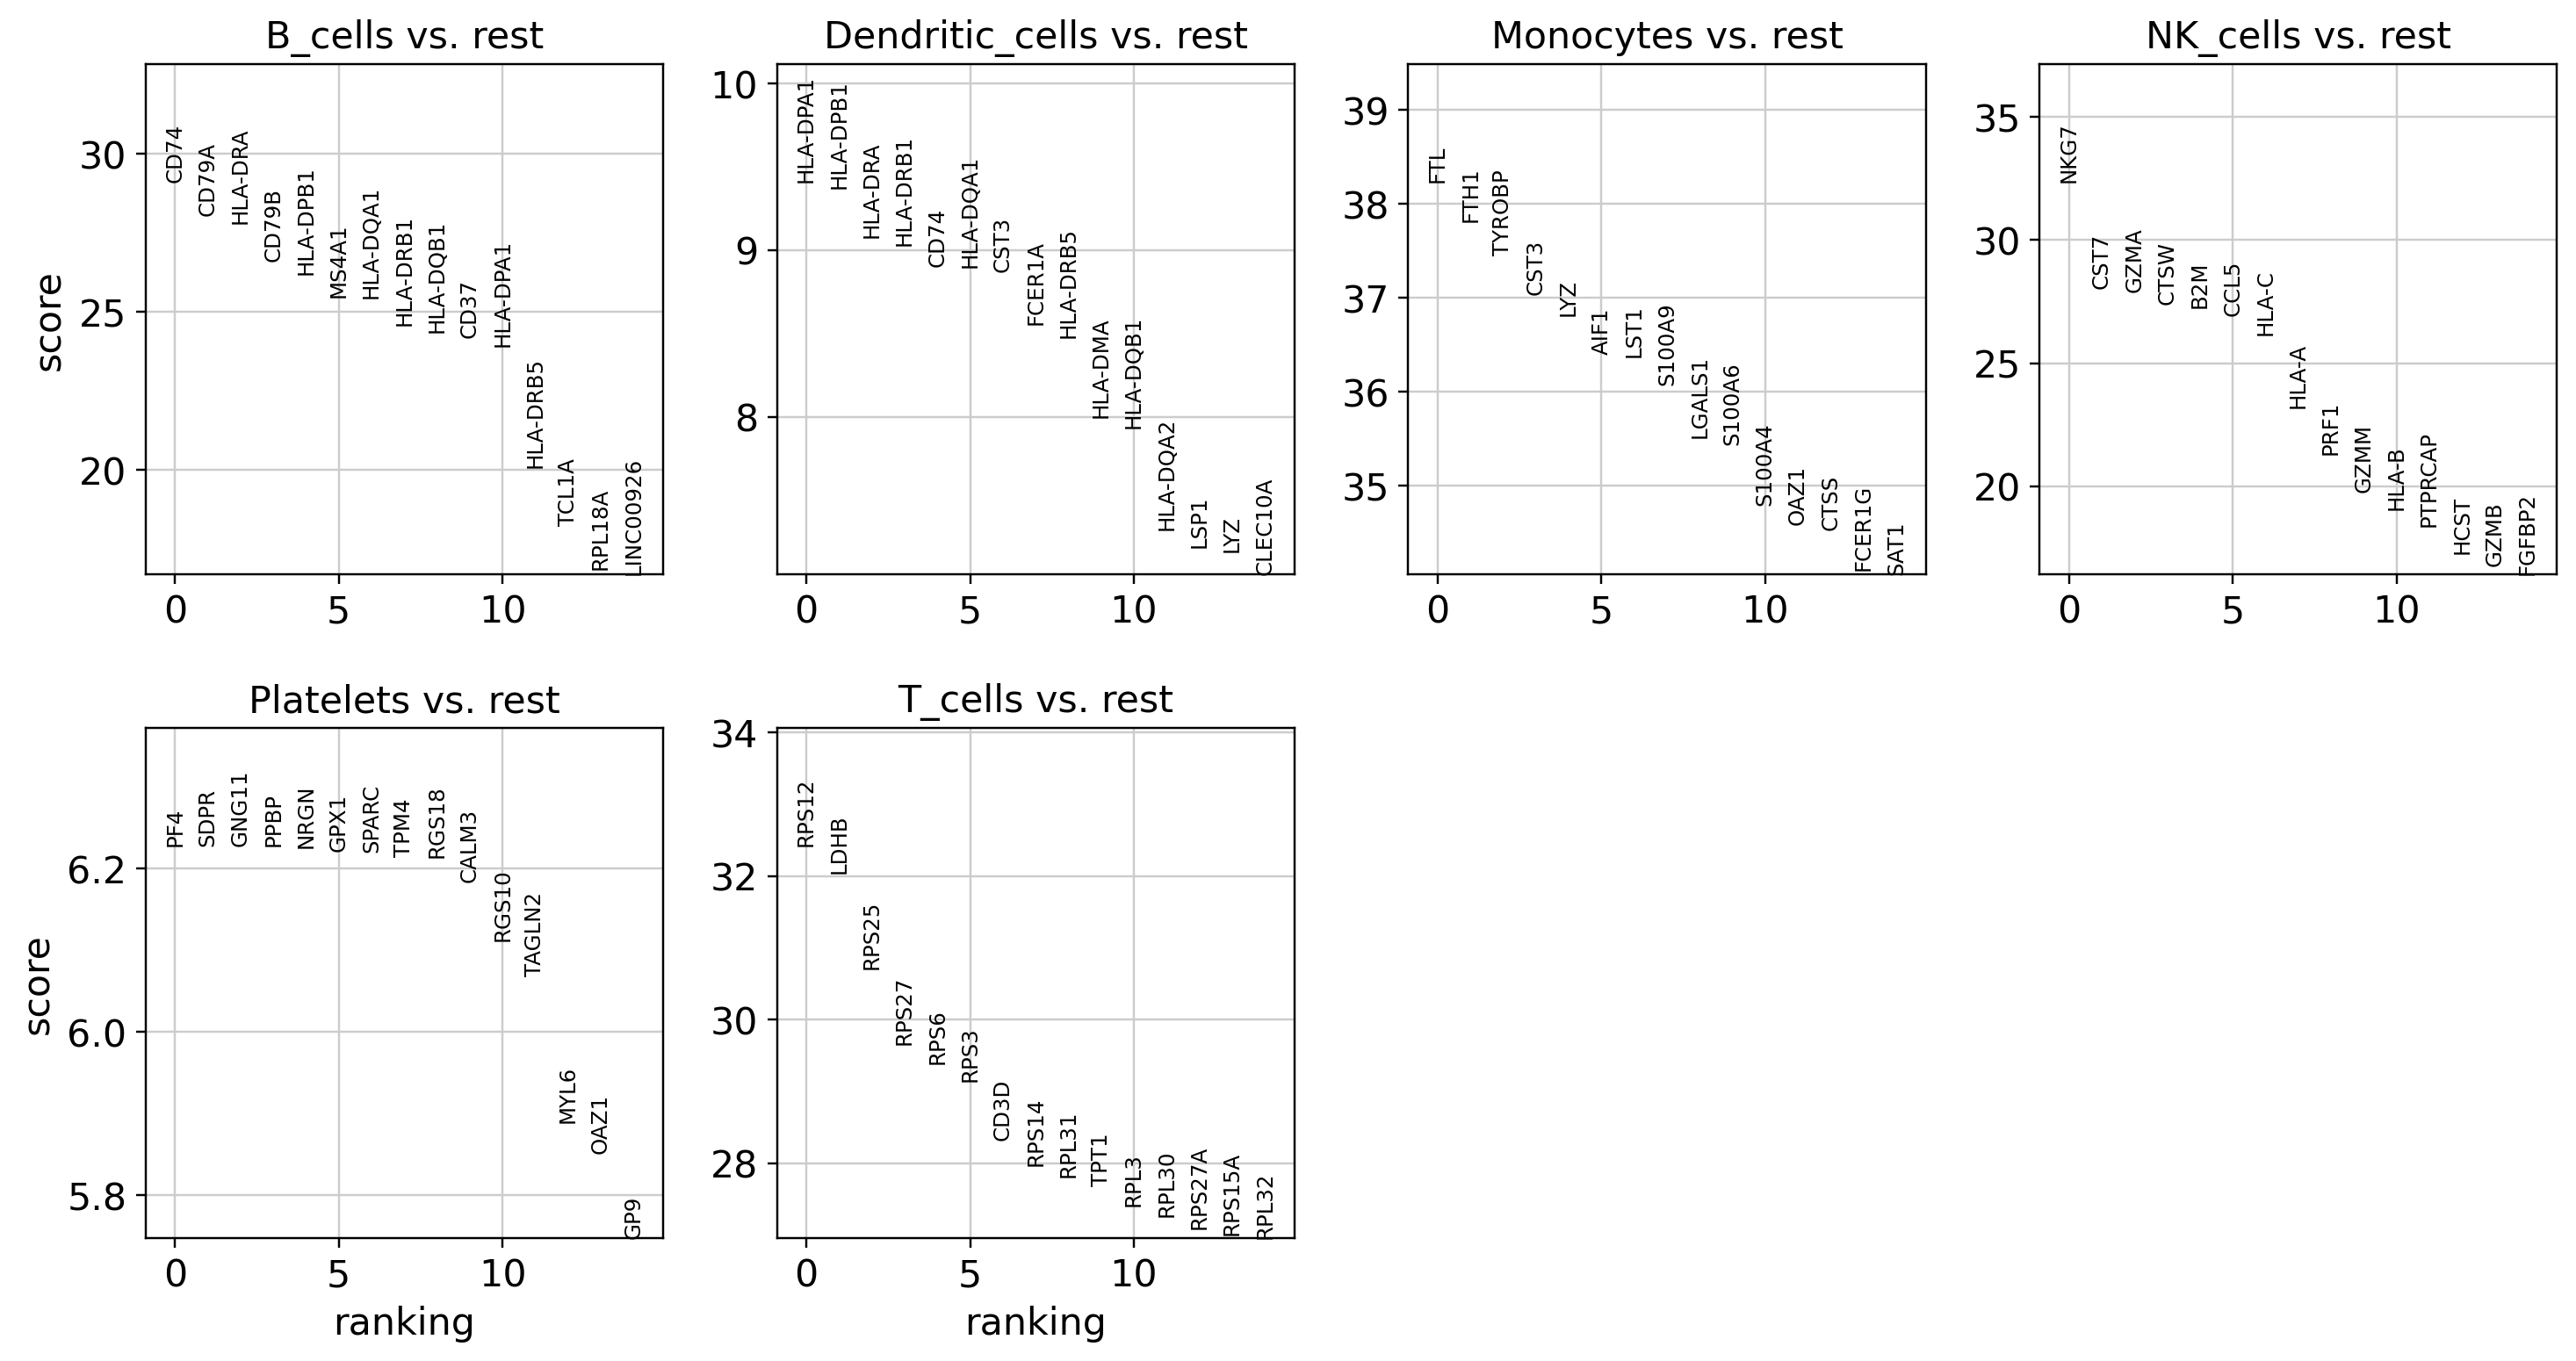


Top markers by annotated cell type:


,group,names,logfoldchanges,pvals_adj
0,B_cells,CD74,4.060195,3.536794e-182
1,B_cells,CD79A,7.718640,3.497950e-169
2,B_cells,HLA-DRA,4.871556,1.585960e-166
3,B_cells,CD79B,5.468642,2.337571e-152
4,B_cells,HLA-DPB1,4.064066,1.104385e-147
5,B_cells,MS4A1,6.454195,1.358140e-139
6,B_cells,HLA-DQA1,5.338094,1.640131e-139
7,B_cells,HLA-DRB1,3.883419,5.496727e-130
13712,Dendritic_cells,HLA-DPA1,4.291121,4.909476e-17
13713,Dendritic_cells,HLA-DPB1,4.454390,4.909476e-17



Cell-type proportions (%):


,percent
cell_type,
T_cells,44.47
Monocytes,24.02
NK_cells,16.63
B_cells,13.07
Dendritic_cells,1.34
Platelets,0.48


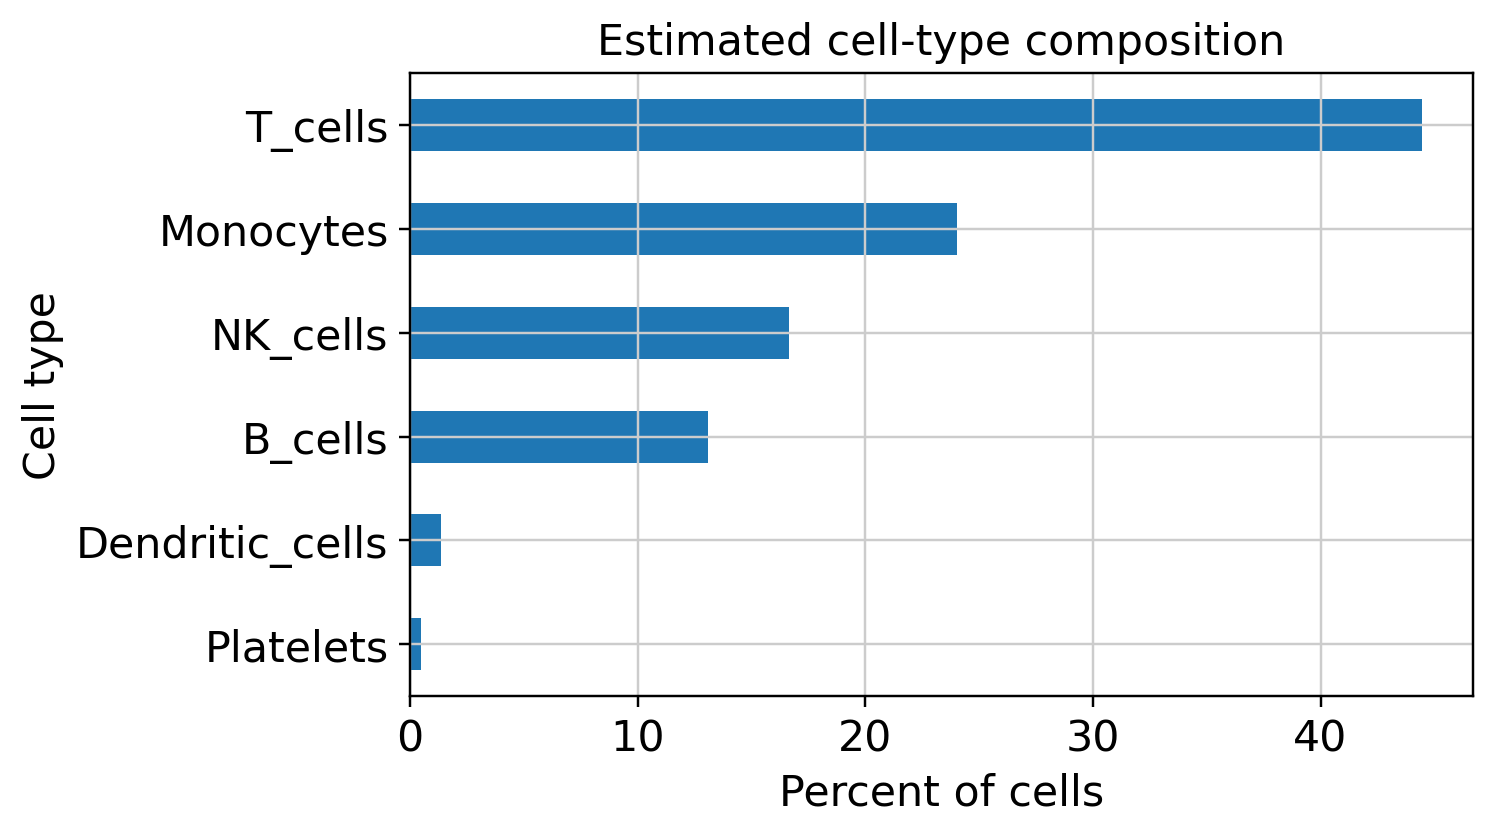


Saved outputs to: scanpy_pbmc3k_outputs
Files:
 - celltype_markers.csv
 - cluster_markers.csv
 - cluster_score_matrix.csv
 - pbmc3k_scanpy_advanced.h5ad

Analysis summary:
n_cells_final: 2694
n_genes_final: 1860
n_clusters: 7
clusters: ['0', '1', '2', '3', '4', '5', '6']
cell_types: ['B_cells', 'Dendritic_cells', 'Monocytes', 'NK_cells', 'Platelets', 'T_cells']


In [1]:
available_reference = {
    celltype: [g for g in genes if g in adata.var_names]
    for celltype, genes in cluster_marker_reference.items()
}
available_reference = {k: v for k, v in available_reference.items() if len(v) > 0}

for celltype, genes in available_reference.items():
    sc.tl.score_genes(adata, gene_list=genes, score_name=f"{celltype}_score", use_raw=False)

score_cols = [f"{ct}_score" for ct in available_reference.keys()]
cluster_scores = adata.obs.groupby("leiden")[score_cols].mean()
display(cluster_scores)

cluster_to_celltype = {}
for cluster in cluster_scores.index:
    best = cluster_scores.loc[cluster].idxmax().replace("_score", "")
    cluster_to_celltype[cluster] = best

adata.obs["cell_type"] = adata.obs["leiden"].map(cluster_to_celltype).astype("category")

print("\nCluster to cell-type mapping:")
display(pd.DataFrame.from_dict(cluster_to_celltype, orient="index", columns=["assigned_cell_type"]))

sc.pl.umap(
    adata,
    color=["leiden", "cell_type"],
    legend_loc="on data",
    wspace=0.45
)

sc.tl.rank_genes_groups(adata, groupby="cell_type", method="wilcoxon")
sc.pl.rank_genes_groups(adata, n_genes=15, sharey=False)

celltype_markers = sc.get.rank_genes_groups_df(adata, group=None)
print("\nTop markers by annotated cell type:")
display(
    celltype_markers.groupby("group").head(8)[["group", "names", "logfoldchanges", "pvals_adj"]]
)

cluster_prop = (
    adata.obs["cell_type"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .rename("percent")
    .to_frame()
)
print("\nCell-type proportions (%):")
display(cluster_prop)

plt.figure(figsize=(7, 4))
cluster_prop["percent"].sort_values().plot(kind="barh")
plt.xlabel("Percent of cells")
plt.ylabel("Cell type")
plt.title("Estimated cell-type composition")
plt.tight_layout()
plt.show()

output_dir = "scanpy_pbmc3k_outputs"
os.makedirs(output_dir, exist_ok=True)

adata.write(os.path.join(output_dir, "pbmc3k_scanpy_advanced.h5ad"))
marker_table.to_csv(os.path.join(output_dir, "cluster_markers.csv"), index=False)
celltype_markers.to_csv(os.path.join(output_dir, "celltype_markers.csv"), index=False)
cluster_scores.to_csv(os.path.join(output_dir, "cluster_score_matrix.csv"))

print(f"\nSaved outputs to: {output_dir}")
print("Files:")
for f in sorted(os.listdir(output_dir)):
    print(" -", f)

summary = {
    "n_cells_final": int(adata.n_obs),
    "n_genes_final": int(adata.n_vars),
    "n_clusters": int(adata.obs["leiden"].nunique()),
    "clusters": sorted(adata.obs["leiden"].unique().tolist()),
    "cell_types": sorted(adata.obs["cell_type"].unique().tolist()),
}
print("\nAnalysis summary:")
for k, v in summary.items():
    print(f"{k}: {v}")